# Module 1: K-Means Clustering Analysis
## Research Question: How do SLM Technologies cluster geographically and environmentally?

This notebook performs k-means clustering on WOCAT SLM Technologies data to identify geographic and environmental clusters.

## 1. Setup and Imports

In [1]:
#!pip install pandas numpy scikit-learn matplotlib seaborn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✓ All imports successful")

✓ All imports successful


## 2. Configuration

Edit these settings to customize your analysis:

In [2]:
# ==================== CONFIGURATION ====================

# Data file path - update this if your file is in a different location
DATA_FILE = '/Users/normankearney/Documents/CAS-AML-WOCAT/colab/datasets/wocat/wocat_technologies.csv.gz'

# Features to include in clustering (mapped to actual column names)
ESSENTIAL_FEATURES = {
    'agroclimatic_zone': 'categorical',
    'slm_group_primary': 'categorical',
}

OPTIONAL_FEATURES = {
    'landuse_primary': 'categorical'
    #'degradation_primary': 'categorical', exclude, low feature importance
    #'imp_ecological_biodiversity': 'numeric', exclude, 41.9% missing
    #'latitude': 'numeric', exclude, dominates clusters, they become essentially regions
    #'longitude': 'numeric', exclude, dominates clusters, they become essentially regions
    #'altitude': 'categorical', exclude, low feature importance
    #'watersupply': 'categorical', # exclude, 14% missing
}

USE_OPTIONAL = True

# K-means grid search parameters
K_MIN = 2
K_MAX = 20
RANDOM_STATE = 42
N_INIT = 10

print(f"Configuration loaded:")
print(f"  Data file: {DATA_FILE}")
print(f"  K range: {K_MIN}-{K_MAX}")

Configuration loaded:
  Data file: /Users/normankearney/Documents/CAS-AML-WOCAT/colab/datasets/wocat/wocat_technologies.csv.gz
  K range: 2-20


## 3. Data Loading and Preparation

In [3]:
def load_and_prepare_data(filepath, use_optional=USE_OPTIONAL):
    """
    Load WOCAT data from gzipped CSV and prepare features for clustering.
    """
    print("Loading WOCAT data from gzipped CSV...")
    
    # Load gzipped CSV
    data = pd.read_csv(filepath, compression='gzip')
    
    print(f"Original dataset shape: {data.shape}")
    
    # Select features
    features_to_use = ESSENTIAL_FEATURES.copy()
    if use_optional:
        features_to_use.update(OPTIONAL_FEATURES)
    
    # Check available columns
    available_features = {}
    for feature_name, feature_type in features_to_use.items():
        if feature_name in data.columns:
            available_features[feature_name] = feature_type
        else:
            print(f"  ⚠ Missing: {feature_name}")
    
    if not available_features:
        raise ValueError(f"No matching features found in data.")
    
    print(f"\n✓ Using {len(available_features)} features:")
    for fname in available_features.keys():
        missing = data[fname].isnull().sum()
        print(f"  - {fname}: {missing} missing values")
    
    # FILTER 1: Remove rows with invalid geographic coordinates
    data_before_geo = len(data)
    data = data[(data['latitude'] >= -90) & (data['latitude'] <= 90) &
                (data['longitude'] >= -180) & (data['longitude'] <= 180)]
    removed_geo = data_before_geo - len(data)
    if removed_geo > 0:
        print(f"\n⚠ Removed {removed_geo} rows with invalid coordinates")
    
    # FILTER 2: Remove rows with missing essential features
    essential_cols = [f for f in ESSENTIAL_FEATURES.keys() if f in available_features]
    data_before_missing = len(data)
    
    # Keep latitude, longitude, altitude, country_name, and biodiversity impacts for plotting/interpretation even if not used as features
    cols_to_keep = list(available_features.keys()) + ['latitude', 'longitude', 'altitude', 'country_name', 'imp_ecological_biodiversity']
    cols_to_keep = [c for c in cols_to_keep if c in data.columns]  # Only keep if they exist
    data = data[cols_to_keep].dropna(subset=essential_cols)
    
    removed_missing = data_before_missing - len(data)
    if removed_missing > 0:
        print(f"Removed {removed_missing} rows with missing essential features")
    
    print(f"\nAfter filtering: {data.shape[0]} technologies ready for clustering")
    print(f"Total removed: {removed_geo + removed_missing} rows\n")
    
    # Prepare feature matrix
    X = prepare_features(data, available_features)
    
    return X, list(available_features.keys()), data

def prepare_features(data, features_dict):
    """
    Prepare and standardize features for clustering.
    
    Numeric variables are standardized (mean=0, std=1).
    Categorical variables are one-hot encoded.
    Multi-label categorical variables (pipe-separated) are multi-hot encoded.
    """
    print("Preparing features...")
    feature_arrays = []
    
    # Features that contain pipe-separated multi-label values
    multi_label_features = {}
    
    for feature_name, feature_type in features_dict.items():
        if feature_type == 'numeric':
            # Standardize numeric features
            values = data[feature_name].values.reshape(-1, 1)
            scaler = StandardScaler()
            scaled = scaler.fit_transform(values)
            feature_arrays.append(scaled)
            print(f"  ✓ {feature_name}: numeric (scaled)")
            print(f"      Range: [{data[feature_name].min():.2f}, {data[feature_name].max():.2f}]")
            
        elif feature_type == 'categorical':
            # Check if this is a multi-label feature (pipe-separated)
            if feature_name in multi_label_features:
                # Handle multi-label features (e.g., "TypeA|TypeB|TypeC")
                encoded = encode_multi_label(data[feature_name], feature_name)
                feature_arrays.append(encoded)
                print(f"  ✓ {feature_name}: multi-label categorical ({encoded.shape[1]} categories)")
            else:
                # Single-label categorical feature
                n_unique = data[feature_name].nunique()
                
                if n_unique > 50:
                    # Keep top 20 categories, group rest as "other"
                    top_categories = data[feature_name].value_counts().head(20).index
                    data_encoded = data[feature_name].copy()
                    data_encoded = data_encoded.where(data_encoded.isin(top_categories), "other")
                else:
                    data_encoded = data[feature_name]
                
                encoded = pd.get_dummies(data_encoded, 
                                       prefix=feature_name, 
                                       drop_first=False,
                                       dummy_na=True)
                feature_arrays.append(encoded.values)
                print(f"  ✓ {feature_name}: categorical ({len(encoded.columns)} categories)")
    
    X = np.hstack(feature_arrays)
    print(f"\nFinal feature matrix shape: {X.shape}")
    print(f"  - {X.shape[0]} samples (SLM technologies)")
    print(f"  - {X.shape[1]} features (after encoding)\n")
    
    return X


def encode_multi_label(series, feature_name):
    """
    Encode pipe-separated multi-label categorical features as binary indicators.
    
    For example: "TypeA|TypeB|TypeC" becomes three binary columns.
    """
    # Split pipe-separated values and get all unique types
    all_types = set()
    for val in series.dropna():
        if isinstance(val, str):
            types = val.split('|')
            all_types.update(types)
    
    all_types = sorted(list(all_types))
    
    # Create binary columns for each type
    encoded = pd.DataFrame(0, index=series.index, 
                          columns=[f"{feature_name}_{t}" for t in all_types])
    
    for idx, val in series.items():
        if pd.notna(val) and isinstance(val, str):
            types = val.split('|')
            for t in types:
                col_name = f"{feature_name}_{t}"
                if col_name in encoded.columns:
                    encoded.loc[idx, col_name] = 1
    
    return encoded.values

In [4]:
# Load data
X, feature_names, data = load_and_prepare_data(DATA_FILE, use_optional=True)


Loading WOCAT data from gzipped CSV...
Original dataset shape: (1540, 51)

✓ Using 3 features:
  - agroclimatic_zone: 27 missing values
  - slm_group_primary: 39 missing values
  - landuse_primary: 43 missing values

⚠ Removed 131 rows with invalid coordinates
Removed 56 rows with missing essential features

After filtering: 1353 technologies ready for clustering
Total removed: 187 rows

Preparing features...
  ✓ agroclimatic_zone: categorical (5 categories)
  ✓ slm_group_primary: categorical (27 categories)
  ✓ landuse_primary: categorical (9 categories)

Final feature matrix shape: (1353, 41)
  - 1353 samples (SLM technologies)
  - 41 features (after encoding)



## 3.5 Data Quality Check

Before clustering, we need to ensure our geographic coordinates are valid. Invalid coordinates can skew results and create spurious clusters.

In [5]:
# ==================== DATA QUALITY CHECK ====================

# Load the raw data first to check quality (before feature preparation)
print("\n" + "="*80)
print("DATA QUALITY CHECK")
print("="*80 + "\n")

raw_data = pd.read_csv(DATA_FILE, compression='gzip')

print(f"Raw dataset shape: {raw_data.shape}\n")

# Check 1: Valid geographic coordinates
print("CHECK 1: Valid Geographic Coordinates")
print("-" * 80)

# Longitude should be -180 to 180
invalid_lon = raw_data[(raw_data['longitude'] < -180) | (raw_data['longitude'] > 180)]
print(f"Invalid longitude values (outside [-180, 180]): {len(invalid_lon)}")

if len(invalid_lon) > 0:
    print("\nRows with invalid longitude:")
    cols_to_show = ['technology_id', 'name', 'country_name', 'latitude', 'longitude']
    cols_to_show = [c for c in cols_to_show if c in invalid_lon.columns]
    print(invalid_lon[cols_to_show].to_string())
    print()

# Latitude should be -90 to 90
invalid_lat = raw_data[(raw_data['latitude'] < -90) | (raw_data['latitude'] > 90)]
print(f"Invalid latitude values (outside [-90, 90]): {len(invalid_lat)}")

if len(invalid_lat) > 0:
    print("\nRows with invalid latitude:")
    cols_to_show = ['technology_id', 'name', 'country_name', 'latitude', 'longitude']
    cols_to_show = [c for c in cols_to_show if c in invalid_lat.columns]
    print(invalid_lat[cols_to_show].to_string())
    print()

# Check 2: Summary statistics for coordinates
print("\nCHECK 2: Coordinate Statistics")
print("-" * 80)
valid_coords = raw_data[(raw_data['longitude'] >= -180) & (raw_data['longitude'] <= 180) &
                        (raw_data['latitude'] >= -90) & (raw_data['latitude'] <= 90)]
print(f"Rows with valid coordinates: {len(valid_coords)}\n")

print("Latitude statistics:")
print(f"  Min: {valid_coords['latitude'].min():.4f}°")
print(f"  Max: {valid_coords['latitude'].max():.4f}°")
print(f"  Mean: {valid_coords['latitude'].mean():.4f}°")
print(f"  Std: {valid_coords['latitude'].std():.4f}°\n")

print("Longitude statistics:")
print(f"  Min: {valid_coords['longitude'].min():.4f}°")
print(f"  Max: {valid_coords['longitude'].max():.4f}°")
print(f"  Mean: {valid_coords['longitude'].mean():.4f}°")
print(f"  Std: {valid_coords['longitude'].std():.4f}°\n")

# Check 3: Missing values in essential columns
print("CHECK 3: Missing Values in Essential Features")
print("-" * 80)
for feat in ESSENTIAL_FEATURES.keys():
    if feat in raw_data.columns:
        missing = raw_data[feat].isnull().sum()
        pct = (missing / len(raw_data)) * 100
        print(f"{feat:20} {missing:4d} missing ({pct:5.1f}%)")

# Check 4: Missing values in optional columns
print("\nCHECK 4: Missing Values in Optional Features")
print("-" * 80)
for feat in OPTIONAL_FEATURES.keys():
    if feat in raw_data.columns:
        missing = raw_data[feat].isnull().sum()
        pct = (missing / len(raw_data)) * 100
        print(f"{feat:20} {missing:4d} missing ({pct:5.1f}%)")

print("\n" + "="*80)
print(f"\nRecommendation: Remove {len(invalid_lon) + len(invalid_lat)} rows with invalid coordinates")
print("This is handled automatically in the clustering process.\n")
print("="*80 + "\n")



DATA QUALITY CHECK

Raw dataset shape: (1540, 51)

CHECK 1: Valid Geographic Coordinates
--------------------------------------------------------------------------------
Invalid longitude values (outside [-180, 180]): 7

Rows with invalid longitude:
      technology_id                                                                     name country_name   latitude      longitude
1012           3269                                                 Sistemas silvopastoriles      Ecuador  -2.072100  321581.287040
1071           3619                                 FLOATING AGRICULTURE IN WATERLOGGED SOIL   Bangladesh  22.850843     270.042361
1137           4123                    Water Storage Ponds in Small-Scale Agricultural Areas     Thailand  14.064538    -259.840364
1181           4391  Using shallow wells for crops and lowering the saline groundwater table     Thailand  15.612598  318342.403591
1420           6829             Geocoding of Million Fruit Trees for Monitoring and Track

## 4. K-Means Grid Search

In [6]:
def grid_search_kmeans(X, k_min=K_MIN, k_max=K_MAX, random_state=RANDOM_STATE):
    """
    Perform grid search to find optimal number of clusters.
    """
    print(f"Performing grid search for k={k_min} to k={k_max}...\n")
    
    results = []
    models = {}
    
    for k in range(k_min, k_max + 1):
        print(f"  k={k:2d}: ", end='', flush=True)
        
        kmeans = KMeans(n_clusters=k, 
                       random_state=random_state,
                       n_init=N_INIT)
        labels = kmeans.fit_predict(X)
        
        # Calculate metrics
        silhouette = silhouette_score(X, labels)
        davies_bouldin = davies_bouldin_score(X, labels)
        calinski_harabasz = calinski_harabasz_score(X, labels)
        inertia = kmeans.inertia_
        
        results.append({
            'k': k,
            'silhouette': silhouette,
            'davies_bouldin': davies_bouldin,
            'calinski_harabasz': calinski_harabasz,
            'inertia': inertia
        })
        
        models[k] = kmeans
        
        print(f"Silhouette={silhouette:6.3f}  DB={davies_bouldin:6.3f}  CH={calinski_harabasz:8.1f}")
    
    results_df = pd.DataFrame(results)
    print(f"\nGrid search complete!\n")
    
    return results_df, models


# Run grid search
results_df, models = grid_search_kmeans(X)

Performing grid search for k=2 to k=20...

  k= 2: Silhouette= 0.184  DB= 2.030  CH=   280.1
  k= 3: Silhouette= 0.241  DB= 1.980  CH=   268.8
  k= 4: Silhouette= 0.234  DB= 1.790  CH=   242.0
  k= 5: Silhouette= 0.257  DB= 1.642  CH=   219.5
  k= 6: Silhouette= 0.274  DB= 1.515  CH=   204.7
  k= 7: Silhouette= 0.229  DB= 1.473  CH=   187.3
  k= 8: Silhouette= 0.230  DB= 1.593  CH=   176.2
  k= 9: Silhouette= 0.235  DB= 1.897  CH=   160.7
  k=10: Silhouette= 0.252  DB= 1.676  CH=   154.5
  k=11: Silhouette= 0.254  DB= 1.552  CH=   148.9
  k=12: Silhouette= 0.266  DB= 1.416  CH=   144.8
  k=13: Silhouette= 0.295  DB= 1.584  CH=   137.6
  k=14: Silhouette= 0.306  DB= 1.456  CH=   138.7
  k=15: Silhouette= 0.298  DB= 1.452  CH=   129.2
  k=16: Silhouette= 0.330  DB= 1.570  CH=   130.2
  k=17: Silhouette= 0.352  DB= 1.416  CH=   125.0
  k=18: Silhouette= 0.384  DB= 1.489  CH=   126.5
  k=19: Silhouette= 0.381  DB= 1.550  CH=   124.0
  k=20: Silhouette= 0.366  DB= 1.526  CH=   122.2

Grid s

## 5. Evaluation Metrics

In [7]:
# Display evaluation metrics table
print("EVALUATION METRICS:\n")
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
print(results_df.to_string(index=False))
print()

EVALUATION METRICS:

 k  silhouette  davies_bouldin  calinski_harabasz     inertia
 2    0.183737        2.030329         280.060270 2276.257857
 3    0.241138        1.979805         268.790017 1965.461366
 4    0.234317        1.790296         242.046952 1786.489578
 5    0.257123        1.641712         219.510156 1664.151744
 6    0.274078        1.515402         204.674475 1561.662337
 7    0.228793        1.472949         187.298565 1497.686468
 8    0.230251        1.593349         176.236792 1433.391194
 9    0.234746        1.896729         160.737362 1404.417826
10    0.252239        1.676225         154.484967 1350.251126
11    0.253613        1.552271         148.883366 1302.789598
12    0.266419        1.415820         144.842897 1255.927429
13    0.295383        1.584496         137.591648 1231.147297
14    0.306480        1.455803         138.711256 1171.052775
15    0.298393        1.451648         129.211053 1168.427404
16    0.330397        1.569646         130.153514

In [8]:
def find_optimal_k(results_df):
    """
    Identify optimal number of clusters based on multiple metrics.
    """
    optimal = {
        'silhouette': int(results_df.loc[results_df['silhouette'].idxmax(), 'k']),
        'davies_bouldin': int(results_df.loc[results_df['davies_bouldin'].idxmin(), 'k']),
        'calinski_harabasz': int(results_df.loc[results_df['calinski_harabasz'].idxmax(), 'k']),
    }
    
    print("="*80)
    print("OPTIMAL NUMBER OF CLUSTERS (by metric):")
    print("="*80)
    print(f"  Silhouette Score:      k={optimal['silhouette']}")
    print(f"  Davies-Bouldin Index:  k={optimal['davies_bouldin']}")
    print(f"  Calinski-Harabasz:     k={optimal['calinski_harabasz']}")
    print("\nRECOMMENDATION: Review visualizations and select k based on")
    print("interpretability and domain knowledge about SLM Technologies.\n")
    print("="*80 + "\n")
    
    return optimal


optimal = find_optimal_k(results_df)

OPTIMAL NUMBER OF CLUSTERS (by metric):
  Silhouette Score:      k=18
  Davies-Bouldin Index:  k=12
  Calinski-Harabasz:     k=2

RECOMMENDATION: Review visualizations and select k based on
interpretability and domain knowledge about SLM Technologies.




## 6. Visualization: Evaluation Metrics

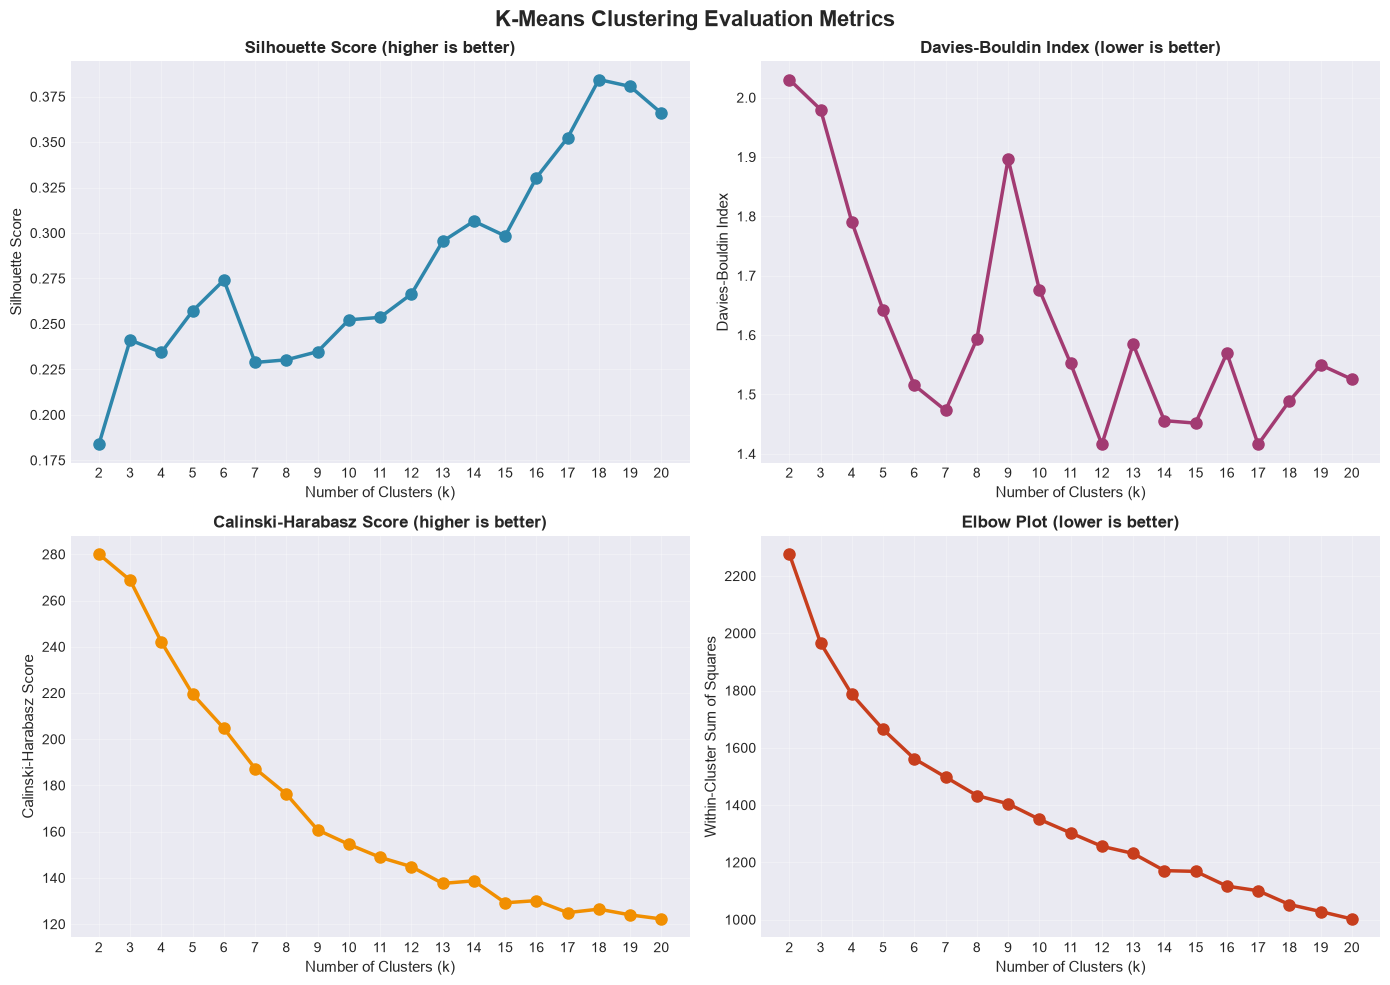

✓ Saved: kmeans_evaluation_metrics.png


In [9]:
def plot_evaluation_metrics(results_df):
    """
    Plot k-means evaluation metrics to identify elbow point.
    """
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle('K-Means Clustering Evaluation Metrics', fontsize=16, fontweight='bold')
    
    # Silhouette Score (higher is better)
    axes[0, 0].plot(results_df['k'], results_df['silhouette'], 'o-', linewidth=2.5, markersize=8, color='#2E86AB')
    axes[0, 0].set_xlabel('Number of Clusters (k)', fontsize=11)
    axes[0, 0].set_ylabel('Silhouette Score', fontsize=11)
    axes[0, 0].set_title('Silhouette Score (higher is better)', fontsize=12, fontweight='bold')
    axes[0, 0].grid(True, alpha=0.3)
    axes[0, 0].set_xticks(results_df['k'])
    
    # Davies-Bouldin Index (lower is better)
    axes[0, 1].plot(results_df['k'], results_df['davies_bouldin'], 'o-', linewidth=2.5, markersize=8, color='#A23B72')
    axes[0, 1].set_xlabel('Number of Clusters (k)', fontsize=11)
    axes[0, 1].set_ylabel('Davies-Bouldin Index', fontsize=11)
    axes[0, 1].set_title('Davies-Bouldin Index (lower is better)', fontsize=12, fontweight='bold')
    axes[0, 1].grid(True, alpha=0.3)
    axes[0, 1].set_xticks(results_df['k'])
    
    # Calinski-Harabasz Score (higher is better)
    axes[1, 0].plot(results_df['k'], results_df['calinski_harabasz'], 'o-', linewidth=2.5, markersize=8, color='#F18F01')
    axes[1, 0].set_xlabel('Number of Clusters (k)', fontsize=11)
    axes[1, 0].set_ylabel('Calinski-Harabasz Score', fontsize=11)
    axes[1, 0].set_title('Calinski-Harabasz Score (higher is better)', fontsize=12, fontweight='bold')
    axes[1, 0].grid(True, alpha=0.3)
    axes[1, 0].set_xticks(results_df['k'])
    
    # Inertia (Elbow method - lower is better)
    axes[1, 1].plot(results_df['k'], results_df['inertia'], 'o-', linewidth=2.5, markersize=8, color='#C73E1D')
    axes[1, 1].set_xlabel('Number of Clusters (k)', fontsize=11)
    axes[1, 1].set_ylabel('Within-Cluster Sum of Squares', fontsize=11)
    axes[1, 1].set_title('Elbow Plot (lower is better)', fontsize=12, fontweight='bold')
    axes[1, 1].grid(True, alpha=0.3)
    axes[1, 1].set_xticks(results_df['k'])
    
    plt.tight_layout()
    plt.savefig('kmeans_evaluation_metrics.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("✓ Saved: kmeans_evaluation_metrics.png")


plot_evaluation_metrics(results_df)

## 7. Run Final Analysis with Selected K

**IMPORTANT:** Review the evaluation metrics above. If you want to use a different k value, edit `SELECTED_K` in the Configuration cell (section 2) and re-run from there.

In [10]:
# Which k to use for final analysis (change this after reviewing evaluation metrics)
SELECTED_K = 6
print(f"SELECTED k = {SELECTED_K} for final analysis\n")

# Get final model and labels
final_model = models[SELECTED_K]
final_labels = final_model.labels_

# Print cluster sizes
unique, counts = np.unique(final_labels, return_counts=True)
print(f"Cluster sizes for k={SELECTED_K}:")
for cluster_id, count in zip(unique, counts):
    pct = (count / len(final_labels)) * 100
    print(f"  Cluster {cluster_id}: {count:4d} technologies ({pct:5.1f}%)")
print()

SELECTED k = 6 for final analysis

Cluster sizes for k=6:
  Cluster 0:  171 technologies ( 12.6%)
  Cluster 1:   95 technologies (  7.0%)
  Cluster 2:  380 technologies ( 28.1%)
  Cluster 3:  466 technologies ( 34.4%)
  Cluster 4:  173 technologies ( 12.8%)
  Cluster 5:   68 technologies (  5.0%)



## 8. Visualization: Geographic Clusters

The scatter plot is drawn on top of country outlines from [Natural Earth](https://www.naturalearthdata.com/) (1:110m, public domain). The GeoJSON file is downloaded once and cached next to the WOCAT dataset, so no extra packages are needed.

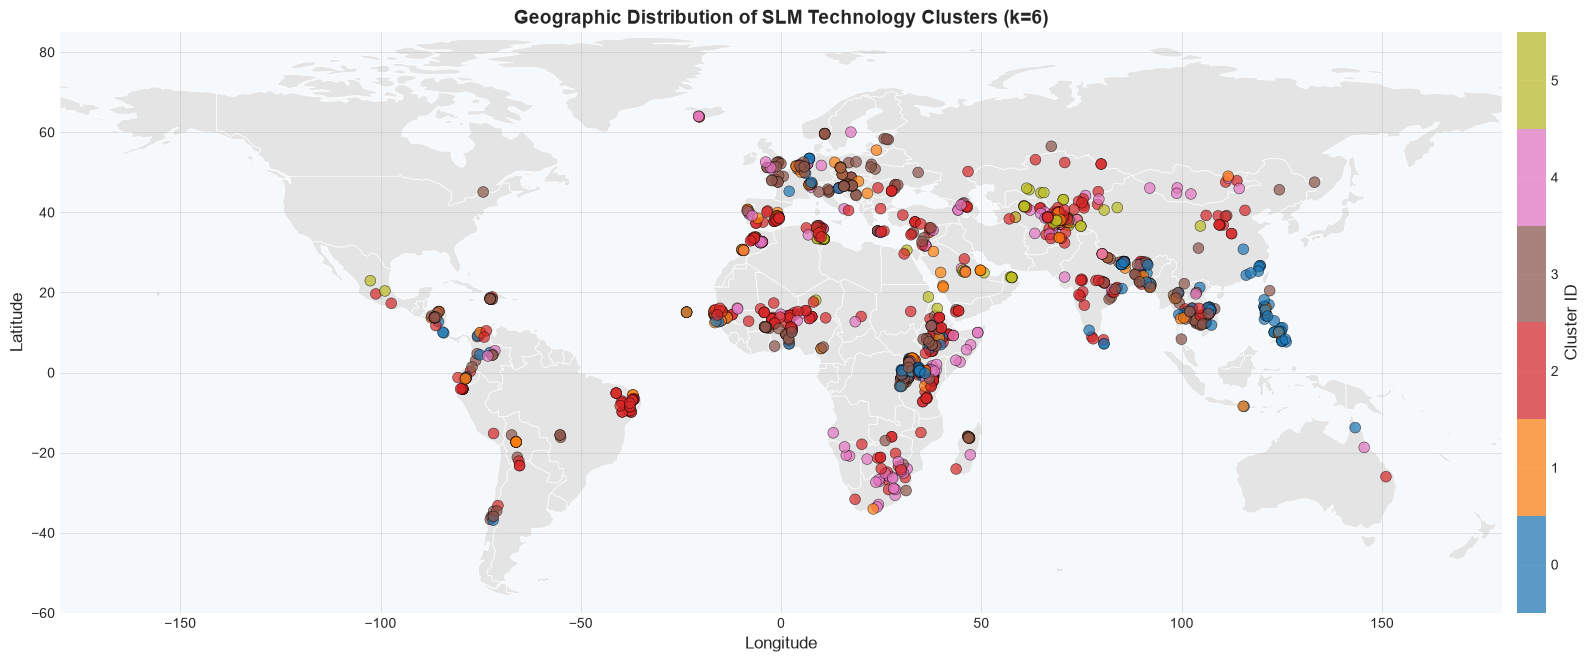

✓ Saved: geographic_clusters_k6.png


In [11]:
import json
import urllib.request
from pathlib import Path
import matplotlib.colors as mcolors
from matplotlib.path import Path as MplPath
from matplotlib.patches import PathPatch
from mpl_toolkits.axes_grid1 import make_axes_locatable

# World basemap: Natural Earth 1:110m country polygons (public domain) as plain GeoJSON.
# Downloaded once and cached next to the WOCAT dataset - no geopandas/cartopy needed.
WORLD_MAP_URL = ('https://raw.githubusercontent.com/nvkelso/natural-earth-vector/'
                 'master/geojson/ne_110m_admin_0_countries.geojson')
WORLD_MAP_FILE = Path(DATA_FILE).parent / 'ne_110m_admin_0_countries.geojson'


def load_world_map(path=WORLD_MAP_FILE, url=WORLD_MAP_URL):
    """
    Return the world map as a GeoJSON FeatureCollection (dict), downloading it on first use.
    Returns None if the file is missing and cannot be downloaded (e.g. offline).
    """
    path = Path(path)
    if not path.is_file():
        try:
            print(f"Downloading world map (Natural Earth 110m) to {path} ...")
            path.parent.mkdir(parents=True, exist_ok=True)
            urllib.request.urlretrieve(url, path)
        except Exception as e:
            print(f"⚠ Could not download world map ({e}) - plotting without basemap.")
            return None
    with open(path, encoding='utf-8') as f:
        return json.load(f)


def draw_world_map(ax, world, land='#e4e4e4', border='white', ocean='#f5f9fc'):
    """
    Draw country polygons as a recessive background layer (x = longitude, y = latitude).
    """
    ax.set_facecolor(ocean)
    if world is None:
        return
    for feature in world['features']:
        geom = feature['geometry']
        polygons = [geom['coordinates']] if geom['type'] == 'Polygon' else geom['coordinates']
        for rings in polygons:
            # rings[0] = outer boundary, rings[1:] = holes (e.g. Lesotho inside South Africa)
            path = MplPath.make_compound_path(*[MplPath(np.asarray(ring)) for ring in rings])
            ax.add_patch(PathPatch(path, facecolor=land, edgecolor=border,
                                   linewidth=0.5, zorder=0))


def plot_geographic_clusters(data, labels, k, world=None):
    """
    Plot clusters on a world map (latitude vs longitude).
    """
    fig, ax = plt.subplots(figsize=(16, 8))
    draw_world_map(ax, world)

    # Select colormap based on k
    if k <= 10:
        cmap_name = 'tab10'
    elif k <= 20:
        cmap_name = 'tab20'
    else:
        cmap_name = 'hsv'

    # Get the colormap
    full_cmap = plt.get_cmap(cmap_name)
    colors = [full_cmap(i / k) for i in range(k)]
    cmap = mcolors.ListedColormap(colors)

    # Create a normalization that maps cluster IDs 0 to k-1
    norm = mcolors.BoundaryNorm(boundaries=np.arange(k + 1) - 0.5, ncolors=k)

    scatter = ax.scatter(data['longitude'], data['latitude'],
                         c=labels, cmap=cmap, norm=norm,
                         s=60, alpha=0.7,
                         edgecolors='black', linewidth=0.4, zorder=3)

    # Whole world without Antarctica; equal aspect so the map is not distorted
    ax.set_xlim(-180, 180)
    ax.set_ylim(-60, 85)
    ax.set_aspect('equal')
    ax.set_xlabel('Longitude', fontsize=12)
    ax.set_ylabel('Latitude', fontsize=12)
    ax.set_title(f'Geographic Distribution of SLM Technology Clusters (k={k})',
                 fontsize=14, fontweight='bold')
    ax.grid(True, color='#b0b0b0', alpha=0.4, linewidth=0.6)

    # Colorbar with discrete ticks for each cluster, same height as the map
    cax = make_axes_locatable(ax).append_axes('right', size='2%', pad=0.15)
    cbar = fig.colorbar(scatter, cax=cax, ticks=range(k))
    cbar.set_label('Cluster ID', fontsize=12)

    fig.tight_layout()
    plt.savefig(f'geographic_clusters_k{k}.png', dpi=300, bbox_inches='tight')
    plt.show()
    print(f"✓ Saved: geographic_clusters_k{k}.png")


world_map = load_world_map()
plot_geographic_clusters(data, final_labels, SELECTED_K, world=world_map)

## 9. Visualization: Cluster Characteristics

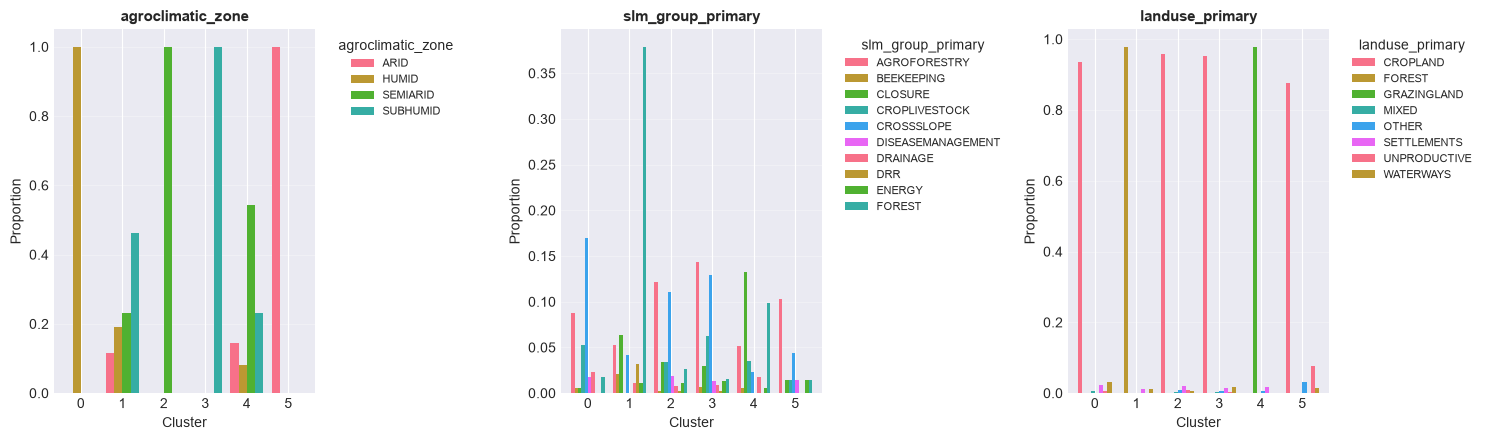

✓ Saved: cluster_characteristics_k6.png


In [12]:
def plot_cluster_characteristics(data, labels, k):
    """
    Visualize key characteristics of each cluster.
    Handles both single-label and multi-label (pipe-separated) categorical features.
    """
    data_with_clusters = data.copy()
    data_with_clusters['cluster'] = labels
    
    if USE_OPTIONAL:
        all_features = {**ESSENTIAL_FEATURES, **OPTIONAL_FEATURES}
    else:
        all_features = ESSENTIAL_FEATURES
    
    # Identify multi-label features
    multi_label_features = {}
    
    # Get categorical columns to visualize
    categorical_cols = []
    for feature_name, feature_type in all_features.items():
        if feature_type == 'categorical' and feature_name in data.columns:
            categorical_cols.append(feature_name)
    
    if len(categorical_cols) == 0:
        print("⚠ No categorical columns found for cluster characteristics plot")
        return
    
    n_cols = min(len(categorical_cols), 3)
    n_rows = (len(categorical_cols) + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4.5*n_rows))
    if n_rows == 1 and n_cols == 1:
        axes = [axes]
    elif n_rows == 1 or n_cols == 1:
        axes = axes.flatten()
    else:
        axes = axes.flatten()
    
    for idx, col in enumerate(categorical_cols):
        if col in data_with_clusters.columns:
            # Handle multi-label features differently
            if col in multi_label_features:
                cluster_distribution = create_multi_label_distribution(
                    data_with_clusters, col
                )
            else:
                # Single-label categorical feature
                cluster_distribution = pd.crosstab(data_with_clusters['cluster'], 
                                                  data_with_clusters[col], 
                                                  normalize='index')
            
            # Limit to top categories if too many
            if cluster_distribution.shape[1] > 10:
                cluster_distribution = cluster_distribution.iloc[:, :10]
            
            cluster_distribution.plot(kind='bar', ax=axes[idx], width=0.8)
            axes[idx].set_title(f'{col}', fontweight='bold', fontsize=11)
            axes[idx].set_xlabel('Cluster')
            axes[idx].set_ylabel('Proportion')
            axes[idx].legend(title=col, bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
            axes[idx].tick_params(axis='x', rotation=0)
            axes[idx].grid(axis='y', alpha=0.3)
    
    # Remove empty subplots
    for idx in range(len(categorical_cols), len(axes)):
        fig.delaxes(axes[idx])
    
    plt.tight_layout()
    plt.savefig(f'cluster_characteristics_k{k}.png', dpi=300, bbox_inches='tight')
    plt.show()
    print(f"✓ Saved: cluster_characteristics_k{k}.png")


def create_multi_label_distribution(data_with_clusters, feature_name):
    """
    Create cluster distribution for multi-label (pipe-separated) features.
    
    Shows the proportion of technologies in each cluster that have each type.
    """
    # Expand pipe-separated values
    all_types = set()
    for val in data_with_clusters[feature_name].dropna():
        if isinstance(val, str):
            types = val.split('|')
            all_types.update(types)
    
    all_types = sorted(list(all_types))
    
    # Create a matrix: rows=clusters, columns=types, values=proportion
    clusters = data_with_clusters['cluster'].unique()
    distribution = pd.DataFrame(0.0, index=sorted(clusters), columns=all_types)
    
    for cluster_id in sorted(clusters):
        cluster_data = data_with_clusters[data_with_clusters['cluster'] == cluster_id]
        cluster_size = len(cluster_data)
        
        # Count how many technologies in this cluster have each type
        for type_name in all_types:
            count = 0
            for val in cluster_data[feature_name].dropna():
                if isinstance(val, str) and type_name in val.split('|'):
                    count += 1
            distribution.loc[cluster_id, type_name] = count / cluster_size if cluster_size > 0 else 0
    
    return distribution


plot_cluster_characteristics(data, final_labels, SELECTED_K)

## 10. Cluster Interpretation

In [13]:
def interpret_clusters(data, labels, k):
    """
    Generate interpretable cluster summaries.
    Handles both single-label and multi-label (pipe-separated) categorical features.
    Also reports biodiversity metrics and countries for reference.
    """
    data_with_clusters = data.copy()
    data_with_clusters['cluster'] = labels
    
    # Combine essential and optional features based on USE_OPTIONAL flag
    if USE_OPTIONAL:
        all_features = {**ESSENTIAL_FEATURES, **OPTIONAL_FEATURES}
    else:
        all_features = ESSENTIAL_FEATURES
    
    # Extract only categorical features
    categorical_features = {name: ftype for name, ftype in all_features.items() 
                           if ftype == 'categorical'}
    
    # Identify multi-label features
    multi_label_features = {}
    
    print("\n" + "="*80)
    print(f"CLUSTER INTERPRETATION (k={k})")
    print("="*80)
    
    for cluster_id in range(k):
        cluster_data = data_with_clusters[data_with_clusters['cluster'] == cluster_id]
        n_samples = len(cluster_data)
        pct = (n_samples / len(data_with_clusters)) * 100
        
        print(f"\n{'─'*80}")
        print(f"CLUSTER {cluster_id:2d}: {n_samples:4d} technologies ({pct:5.1f}%)")
        print(f"{'─'*80}")
        
        # Countries (if available)
        if 'country_name' in cluster_data.columns:
            countries = cluster_data['country_name'].dropna().unique()
            if len(countries) > 0:
                print(f"\nCountries: {', '.join(sorted(countries))}")
        
        # Numeric features: show mean values
        numeric_cols = cluster_data.select_dtypes(include=[np.number]).columns.tolist()
        if 'cluster' in numeric_cols:
            numeric_cols.remove('cluster')
        
        if numeric_cols:
            print("\nDescriptives (not used as features):")
            for col in numeric_cols[:5]:  # Limit to top 5
                if col in ['latitude', 'longitude', 'imp_ecological_biodiversity']:
                    mean_val = cluster_data[col].mean()
                    std_val = cluster_data[col].std()
                    print(f"  {col:25} Mean={mean_val:8.2f}, Std={std_val:6.2f}")

        # Altitude (if available - categorical descriptive)
        if 'altitude' in cluster_data.columns:
            print(f"\nAltitude:")
            altitude_counts = cluster_data['altitude'].value_counts()
            for value, count in altitude_counts.items():
                pct_cat = (count / n_samples) * 100
                if pd.isna(value):
                    value_str = "(Missing)"
                else:
                    value_str = str(value)[:40]
                print(f"  - {value_str:40} {count:3d} ({pct_cat:5.1f}%)")
        
        # Categorical features: show distribution (dynamically from config)
        for col in categorical_features.keys():
            if col in cluster_data.columns:
                print(f"\n{col}:")
                
                # Handle multi-label features differently
                if col in multi_label_features:
                    type_counts = get_multi_label_counts(cluster_data[col])
                    # Sort by count and show top 5
                    for type_name, count in sorted(type_counts.items(), key=lambda x: x[1], reverse=True)[:5]:
                        pct_cat = (count / n_samples) * 100
                        print(f"  - {type_name:40} {count:3d} ({pct_cat:5.1f}%)")
                else:
                    # Single-label categorical feature
                    value_counts = cluster_data[col].value_counts().head(5)
                    for value, count in value_counts.items():
                        pct_cat = (count / n_samples) * 100
                        if pd.isna(value):
                            value_str = "(Missing)"
                        else:
                            value_str = str(value)[:40]
                        print(f"  - {value_str:40} {count:3d} ({pct_cat:5.1f}%)")


def get_multi_label_counts(series):
    """
    Count occurrences of each type in pipe-separated multi-label feature.
    
    Returns a dict with each type and how many technologies have it.
    """
    type_counts = {}
    
    for val in series.dropna():
        if isinstance(val, str):
            types = val.split('|')
            for t in types:
                type_counts[t] = type_counts.get(t, 0) + 1
    
    return type_counts


# Call it with just the required parameters
interpret_clusters(data, final_labels, SELECTED_K)


CLUSTER INTERPRETATION (k=6)

────────────────────────────────────────────────────────────────────────────────
CLUSTER  0:  171 technologies ( 12.6%)
────────────────────────────────────────────────────────────────────────────────

Countries: Australia, Bangladesh, Benin, Bhutan, Burundi, Cabo Verde, Cameroon, Chile, China, Colombia, Costa Rica, Ecuador, Ethiopia, France, Germany, India, Indonesia, Kenya, Laos, Luxembourg, Nepal, Nicaragua, Philippines, Senegal, Slovenia, Sri Lanka, Switzerland, Thailand, Uganda, Vietnam

Descriptives (not used as features):
  latitude                  Mean=   14.20, Std= 13.65
  longitude                 Mean=   64.14, Std= 51.89
  imp_ecological_biodiversity Mean=    1.32, Std=  1.22

Altitude:
  - 500_1000                                  41 ( 24.0%)
  - 1000_1500                                 34 ( 19.9%)
  - 100_500                                   33 ( 19.3%)
  - 0_100                                     26 ( 15.2%)
  - 1500_2000              


FEATURE IMPORTANCE FOR CLUSTERING

Based on between-cluster variance (higher = more important for differentiating clusters)

agroclimatic_zone         0.7820
slm_group_primary         0.1287
landuse_primary           0.3997



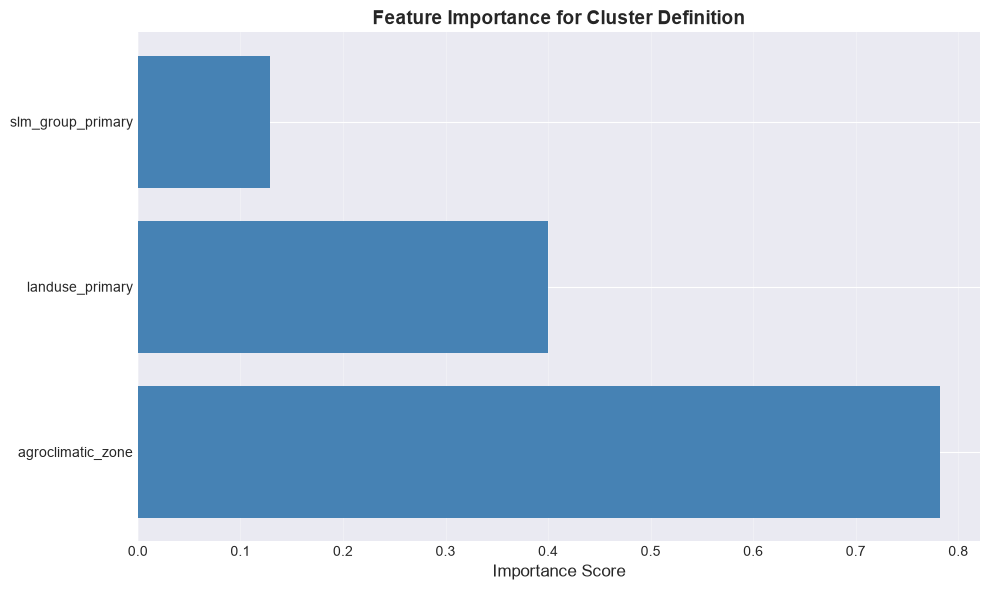

✓ Saved: feature_importance_k6.png



In [14]:
def calculate_feature_importance(data, labels, k):
    """
    Calculate and visualize feature importance for clustering.
    
    Shows which features contribute most to differentiating the clusters.
    Uses between-cluster variance / total variance as the importance metric.
    """
    from sklearn.preprocessing import LabelEncoder
    
    data_with_clusters = data.copy()
    data_with_clusters['cluster'] = labels
    
    if USE_OPTIONAL:
        all_features = {**ESSENTIAL_FEATURES, **OPTIONAL_FEATURES}
    else:
        all_features = ESSENTIAL_FEATURES
    
    print("\n" + "="*80)
    print("FEATURE IMPORTANCE FOR CLUSTERING")
    print("="*80)
    print("\nBased on between-cluster variance (higher = more important for differentiating clusters)")
    print()
    
    importance_scores = {}
    
    for feature_name, feature_type in all_features.items():
        if feature_name not in data.columns:
            continue
        
        if feature_type == 'numeric':
            # For numeric features: calculate between-cluster variance / total variance
            feature_data = data_with_clusters[feature_name].dropna()
            cluster_labels = labels[data_with_clusters[feature_name].notna()]
            
            if len(feature_data) > 0:
                # Overall variance
                total_var = feature_data.var()
                
                # Between-cluster variance (variance of cluster means)
                cluster_means = feature_data.groupby(cluster_labels).mean()
                global_mean = feature_data.mean()
                between_var = ((cluster_means - global_mean) ** 2).sum() / len(cluster_means)
                
                # Importance = between / total
                if total_var > 0:
                    importance = between_var / total_var
                else:
                    importance = 0
                
                importance_scores[feature_name] = importance
                print(f"{feature_name:25} {importance:.4f}")
        
        else:  # categorical
            # For categorical features: use chi-square statistic / max chi-square
            feature_data = data_with_clusters[feature_name].dropna()
            cluster_labels = labels[data_with_clusters[feature_name].notna()]
            
            if len(feature_data) > 0:
                # Create contingency table
                contingency = pd.crosstab(cluster_labels, feature_data)
                
                # Calculate chi-square statistic
                try:
                    from scipy.stats import chi2_contingency
                    chi2, p_value, dof, expected = chi2_contingency(contingency)
                    
                    # Normalize: chi2 / max possible chi2
                    # Max chi2 = n * min(n_clusters - 1, n_categories - 1)
                    n = contingency.sum().sum()
                    max_chi2 = n * min(k - 1, len(feature_data.unique()) - 1)
                    
                    if max_chi2 > 0:
                        importance = chi2 / max_chi2
                    else:
                        importance = 0
                except:
                    importance = 0
                
                importance_scores[feature_name] = importance
                print(f"{feature_name:25} {importance:.4f}")
    
    print("\n" + "="*80)
    
    # Visualize importance scores
    if importance_scores:
        plt.figure(figsize=(10, 6))
        features = list(importance_scores.keys())
        scores = list(importance_scores.values())
        
        # Sort by importance
        sorted_items = sorted(zip(features, scores), key=lambda x: x[1], reverse=True)
        features_sorted = [x[0] for x in sorted_items]
        scores_sorted = [x[1] for x in sorted_items]
        
        plt.barh(features_sorted, scores_sorted, color='steelblue')
        plt.xlabel('Importance Score', fontsize=12)
        plt.title('Feature Importance for Cluster Definition', fontsize=14, fontweight='bold')
        plt.grid(axis='x', alpha=0.3)
        plt.tight_layout()
        plt.savefig(f'feature_importance_k{k}.png', dpi=300, bbox_inches='tight')
        plt.show()
        print(f"✓ Saved: feature_importance_k{k}.png\n")
    
    return importance_scores


# Calculate and display feature importance
importance_scores = calculate_feature_importance(data, final_labels, SELECTED_K)

In [15]:
def print_cluster_centers(data, labels, k):
    """
    Show the mean/mode values for each feature in each cluster.
    """
    data_with_clusters = data.copy()
    data_with_clusters['cluster'] = labels
    
    if USE_OPTIONAL:
        all_features = {**ESSENTIAL_FEATURES, **OPTIONAL_FEATURES}
    else:
        all_features = ESSENTIAL_FEATURES
    
    print("\n" + "="*80)
    print("CLUSTER CENTERS (Mean/Mode Values)")
    print("="*80)
    
    for cluster_id in range(k):
        cluster_data = data_with_clusters[data_with_clusters['cluster'] == cluster_id]
        print(f"\nCLUSTER {cluster_id}:")
        print("-"*80)
        
        for feature_name, feature_type in all_features.items():
            if feature_name not in cluster_data.columns:
                continue
            
            if feature_type == 'numeric':
                mean_val = cluster_data[feature_name].mean()
                std_val = cluster_data[feature_name].std()
                print(f"  {feature_name:25} {mean_val:10.2f} (±{std_val:6.2f})")
            else:
                mode_val = cluster_data[feature_name].mode()
                if len(mode_val) > 0:
                    print(f"  {feature_name:25} {mode_val[0]}")
                else:
                    print(f"  {feature_name:25} (no mode)")


print_cluster_centers(data, final_labels, SELECTED_K)


CLUSTER CENTERS (Mean/Mode Values)

CLUSTER 0:
--------------------------------------------------------------------------------
  agroclimatic_zone         HUMID
  slm_group_primary         CROSSSLOPE
  landuse_primary           CROPLAND

CLUSTER 1:
--------------------------------------------------------------------------------
  agroclimatic_zone         SUBHUMID
  slm_group_primary         FOREST
  landuse_primary           FOREST

CLUSTER 2:
--------------------------------------------------------------------------------
  agroclimatic_zone         SEMIARID
  slm_group_primary         GROUNDCOVER
  landuse_primary           CROPLAND

CLUSTER 3:
--------------------------------------------------------------------------------
  agroclimatic_zone         SUBHUMID
  slm_group_primary         GROUNDCOVER
  landuse_primary           CROPLAND

CLUSTER 4:
--------------------------------------------------------------------------------
  agroclimatic_zone         SEMIARID
  slm_group_prima

## 11. Save Results

In [ ]:
# Save grid search results
results_df.to_csv('kmeans_grid_search_results.csv', index=False)
print(f"✓ Saved: kmeans_grid_search_results.csv")

# Save data with cluster assignments
output_data = data.copy()
output_data['cluster'] = final_labels
output_data.to_csv(f'wocat_data_with_clusters_k{SELECTED_K}.csv', index=False)
print(f"✓ Saved: wocat_data_with_clusters_k{SELECTED_K}.csv")

print(f"\n" + "="*80)
print("ANALYSIS COMPLETE!")
print("="*80)

## Summary

### Next Steps

1. **Try different k values:** Edit `SELECTED_K` in the Configuration cell and re-run the analysis
2. **Investigate cluster patterns:** Use the cluster interpretations and visualizations to understand what makes each cluster distinct
3. **Domain validation:** Compare the clusters with known geographic and agronomic regions
4. **Move to Module 2:** Use the clustered data for supervised learning analysis of biodiversity improvements

### Output Files

- `kmeans_evaluation_metrics.png` - Comparison of 4 evaluation metrics
- `geographic_clusters_k{k}.png` - Map showing geographic distribution of clusters
- `cluster_characteristics_k{k}.png` - Feature distributions by cluster
- `kmeans_grid_search_results.csv` - Raw evaluation metrics for k=2 to k=20
- `wocat_data_with_clusters_k{k}.csv` - Original data with cluster assignments

# Understanding the Clustering Metrics

This cell explains the four metrics used to evaluate k-means clustering quality.

---

## 1. Silhouette Score (range: -1 to 1)

**What it measures:** How well each point fits in its cluster compared to other clusters.

**How it works:**
- For each point, calculate:
  - `a` = average distance to other points in the same cluster (cohesion—lower is better)
  - `b` = average distance to points in the nearest other cluster (separation—higher is better)
  - Silhouette = (b - a) / max(a, b)

**Interpretation:**
- **+1** = Point is very close to its cluster, far from others (perfect)
- **0** = Point is on the boundary between clusters
- **-1** = Point is closer to other clusters than its own (worst case)

**Rule of thumb:**
- **> 0.7** = Strong structure detected
- **0.5-0.7** = Reasonable structure
- **0.25-0.5** = Weak structure
- **< 0.25** = No substantial structure

---

## 2. Davies-Bouldin Index (lower is better, no fixed range)

**What it measures:** The average similarity between each cluster and its most similar cluster.

**How it works:**
- For each cluster, find which other cluster is most similar to it
- Calculate how similar they are (ratio of within-cluster variance)
- Average this across all clusters
- Lower values mean clusters are more distinct from each other

**Interpretation:**
- **< 1.0** = Excellent cluster separation
- **1.0-1.5** = Good separation
- **1.5-2.5** = Reasonable separation
- **> 2.5** = Poor separation, clusters overlap significantly

**Why it matters:** Davies-Bouldin directly measures whether your clusters are actually different from each other, not just whether points cluster tightly.

---

## 3. Calinski-Harabasz Index (higher is better)

**What it measures:** The ratio of between-cluster variance to within-cluster variance.

**How it works:**
- **Between-cluster variance:** How far apart cluster centers are from each other
- **Within-cluster variance:** How spread out points are within each cluster
- Index = (between-cluster / within-cluster) × scaling factor

A high ratio means clusters are compact and well-separated.

**Interpretation:**
- **> 100** = Excellent structure
- **50-100** = Good structure
- **25-50** = Acceptable structure
- **< 25** = Poor structure

**Why it matters:** Unlike silhouette, this metric rewards both tightness AND separation, making it good for finding the "natural" number of clusters.

---

## 4. Inertia (Elbow Method, lower is better)

**What it measures:** Sum of squared distances from each point to its cluster center.

**How it works:**
- For each point: calculate distance to its cluster center, square it
- Sum across all points
- This is what k-means algorithm actually minimizes

**Interpretation:**
- Always decreases as k increases (adding more clusters means lower total distance)
- Look for the "elbow"—where the curve changes slope dramatically
- The elbow suggests the point of diminishing returns

**Why it matters:** Inertia directly reflects what k-means is optimizing for. The elbow is where adding more clusters stops being "worth it."

---

## Comparing the Metrics

| Metric | What it Favors | Interpretation |
|--------|---|---|
| **Silhouette** | Well-separated, cohesive clusters | How much individual points fit |
| **Davies-Bouldin** | Distinct, non-overlapping clusters | Whether clusters are actually different |
| **Calinski-Harabasz** | Compact clusters with distance between centers | Balance of tightness + separation |
| **Inertia (Elbow)** | Lowest total within-cluster distance | Diminishing returns |

---

## How to Use These Results

### Step 1: Look at the Evaluation Metrics Table
Review the numbers for each k value to spot patterns.

### Step 2: Review the Evaluation Metrics Plot
Four subplots show the trends:
- **Silhouette**: Should peak at an optimal k
- **Davies-Bouldin**: Should have a minimum at an optimal k
- **Calinski-Harabasz**: Should peak, then decline
- **Elbow**: Look for a bend in the curve

### Step 3: Look for Consensus
- **If metrics agree** (e.g., all favor k=3): That's likely your optimal k
- **If metrics disagree**: Consider your research goals
  - Need tight, distinct clusters? → favor silhouette/davies-bouldin
  - Need balance? → favor calinski-harabasz
  - Want granular sub-groups? → use higher k even if metrics favor lower

### Step 4: Validate with Domain Knowledge
- Do the resulting clusters make geographic/agronomic sense?
- Can you interpret and explain each cluster?
- Are cluster sizes reasonable (not one huge cluster + tiny ones)?

---

## Common Pitfalls to Avoid

❌ **Don't automatically use the k with the highest silhouette score** if it doesn't make domain sense

❌ **Don't ignore all metrics in favor of one** — look for consensus

❌ **Don't use k=1** — that's "all data is one cluster" (trivially high silhouette)

❌ **Don't use very high k** — you'll get arbitrarily small clusters that don't generalize

✅ **Do consider interpretability** — can you explain each cluster to a colleague?

✅ **Do try multiple k values** — see how geography and technology patterns change

✅ **Do validate results** — do clusters align with known regions or agronomic zones?